In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
forecasted_temps=pd.read_csv("../DataFrames/forcastedTemps(2023-2025).csv")
forecasted_temps.drop(columns={"Unnamed: 0"}, inplace=True)

forecasted_temps["ds"]=pd.to_datetime(forecasted_temps["ds"])

#forecasted_2023=forecasted_temps[forecasted_temps["ds"].dt.year==2023].reset_index(drop=True)
#forecasted_2024=forecasted_temps[forecasted_temps["ds"].dt.year==2024].reset_index(drop=True)
#forecasted_2025=forecasted_temps[forecasted_temps["ds"].dt.year==2025].reset_index(drop=True)
print(forecasted_temps)

             ds       yhat
0    2022-12-30  35.787764
1    2022-12-31  35.602827
2    2023-01-01  35.535912
3    2023-01-02  35.455584
4    2023-01-03  35.505547
...         ...        ...
1090 2025-12-24  36.561437
1091 2025-12-25  36.374383
1092 2025-12-26  36.281875
1093 2025-12-27  36.075685
1094 2025-12-28  35.991556

[1095 rows x 2 columns]


In [19]:
real_temps=pd.read_csv("../DataFrames/NY_AvgTemp(2023-2025).csv")


real_temps=real_temps[real_temps["county_name"]=="New York"]
real_temps=real_temps[["date", "tavg"]]
real_temps["date"]=real_temps["date"].astype("string")
real_temps["date"]=real_temps["date"].str[:4]+'-'+real_temps["date"].str[4:6]+'-'+real_temps["date"].str[6:]
real_temps["date"]=pd.to_datetime(real_temps["date"])
real_temps["tavg"]=(real_temps["tavg"]*1.8)+30

#real_2023=real_temps[real_temps["date"].dt.year==2023].reset_index(drop=True)
#real_2024=real_temps[real_temps["date"].dt.year==2024].reset_index(drop=True)
#real_2025=real_temps[real_temps["date"].dt.year==2025].reset_index(drop=True)



C:\Users\fdram\AppData\Local\Temp\ipykernel_26204\4033501437.py:1: DtypeWarning: Columns (0: stability) have mixed types. Specify dtype option on import or set low_memory=False.
  real_temps=pd.read_csv("../DataFrames/NY_AvgTemp(2023-2025).csv")


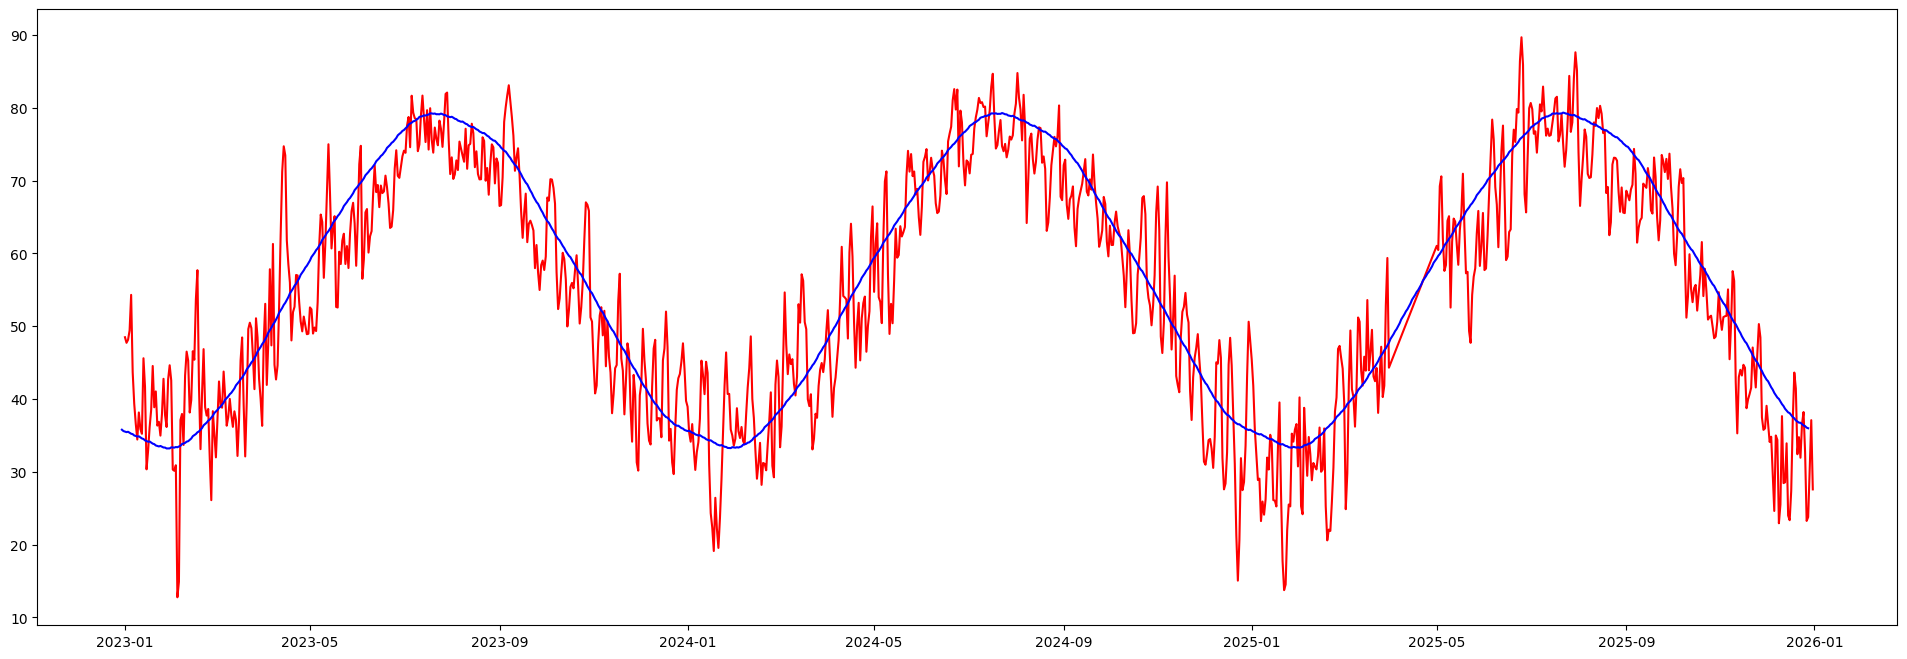

In [20]:
#Graphing both the real and forecasted temperatures for 2023
plt.figure(figsize=(24, 8))
plt.plot(real_temps["date"], real_temps["tavg"], color='red', label='Real Data' )
plt.plot(forecasted_temps['ds'], forecasted_temps["yhat"], color='blue', label='Forecasted Data' )

In [21]:
df_1896_1899=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df_1896_1899["DATE"]=pd.to_datetime(df_1896_1899["DATE"])
df_1896_1899=df_1896_1899[(df_1896_1899["DATE"].dt.year>=1896) & (df_1896_1899["DATE"].dt.year<1899)].reset_index(drop=True)
df_1896_1899["Temp"]=(df_1896_1899["TMIN"]+df_1896_1899["TMAX"])/2
df_1896=df_1896_1899[["DATE", "Temp"]]
print(df_1896_1899)


           DATE  PRCP  SNOW  SNWD  TMIN  TMAX  Temp
0    1896-01-01  0.00   0.0   NaN  26.0  34.0  30.0
1    1896-01-02  0.00   0.0   NaN  26.0  46.0  36.0
2    1896-01-03  0.00   0.0   NaN  24.0  45.0  34.5
3    1896-01-04  0.00   0.0   NaN  13.0  24.0  18.5
4    1896-01-05  0.00   0.0   NaN   6.0  18.0  12.0
...         ...   ...   ...   ...   ...   ...   ...
1091 1898-12-27  0.00   0.0   NaN  31.0  38.0  34.5
1092 1898-12-28  0.00   0.0   NaN  19.0  34.0  26.5
1093 1898-12-29  0.00   0.0   NaN  26.0  45.0  35.5
1094 1898-12-30  0.00   0.0   NaN  43.0  57.0  50.0
1095 1898-12-31  0.36   1.0   NaN  18.0  53.0  35.5

[1096 rows x 7 columns]


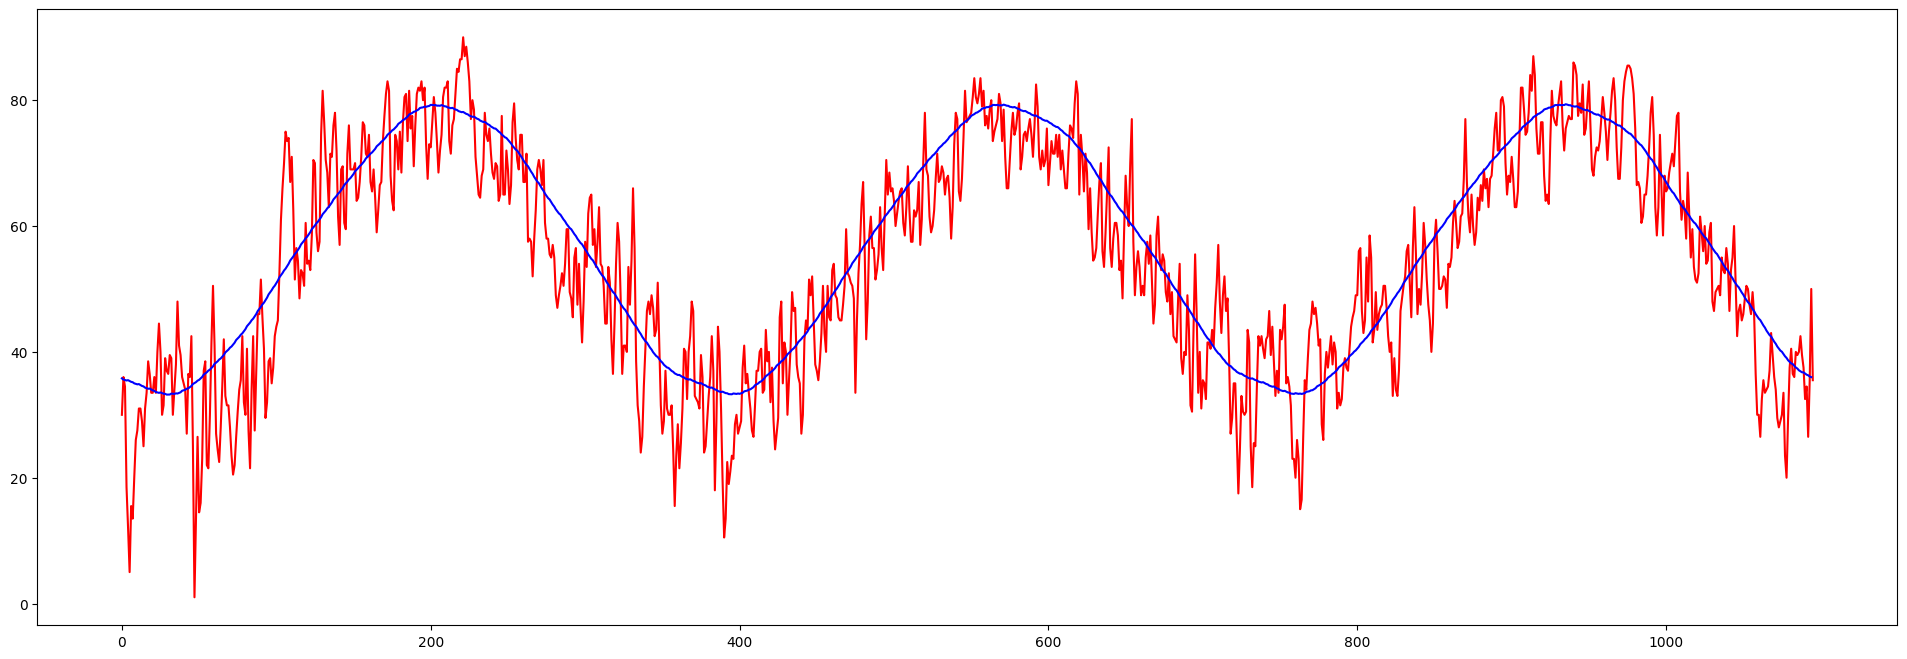

In [22]:
plt.figure(figsize=(24, 8))
plt.plot(df_1896_1899.index, df_1896_1899["Temp"], color='red', label='Real Data' )
plt.plot(forecasted_temps.index, forecasted_temps["yhat"], color='blue', label='Forecasted Data' )

In [23]:
real_temps_Avg=real_temps.groupby(real_temps["date"].dt.year)["tavg"].mean()
print(real_temps_Avg)

yearlyAvg_1896_1899=df_1896_1899.groupby(df_1896_1899["DATE"].dt.year)["Temp"].mean()
print(yearlyAvg_1896_1899)

date
2023    55.344444
2024    55.401413
2025    53.971942
Name: tavg, dtype: float64
DATE
1896    53.676230
1897    53.724658
1898    55.158904
Name: Temp, dtype: float64
